# **R : Experiment - 7**

Mohd Talha Patrawala

CMPN - B

23102B0025

---


## Problem Statement
An e-commerce company wants to understand its customers and improve marketing decisions. Using historical online retail transactions, this notebook:

1. Preprocesses transactions and builds customer-level features (Recency, Frequency, Monetary value, average transaction value, quantity purchased, purchase frequency).
2. Segments customers with **K-Means** (Elbow Method for K) and compares it with **Hierarchical Clustering** (dendrogram), evaluated with the **Silhouette Score**.
3. Visualises segments with a **2D PCA** projection and builds **cluster profiles**.
4. Identifies a **high-value segment** and predicts membership with **Random Forest** and **SVM**, compared using Accuracy, Precision, Recall, F1, ROC-AUC and Confusion Matrix.
5. Analyses **feature importance**, builds an **interactive 3D Plotly** view, and gives **segment-wise marketing recommendations**.



---





## Dataset Description
UCI Machine Learning Repository, *Online Retail* dataset: 541,909 transactions of a UK-based online retailer (01-Dec-2010 to 09-Dec-2011).

| Column | Meaning |
|---|---|
| InvoiceNo | Invoice number (prefix **C** = cancellation) |
| StockCode | Product code |
| Description | Product name |
| Quantity | Units per transaction |
| InvoiceDate | Date and time of the invoice |
| UnitPrice | Price per unit (GBP) |
| CustomerID | Customer identifier |
| Country | Customer country |



---



In [1]:
!pip install -q kneed

In [2]:
import os, zipfile, urllib.request, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.inspection import permutation_importance
from sklearn.metrics import (silhouette_score, adjusted_rand_score, accuracy_score,
                             precision_score, recall_score, f1_score, roc_auc_score,
                             confusion_matrix, ConfusionMatrixDisplay, roc_curve,
                             classification_report)
from scipy.cluster.hierarchy import linkage, dendrogram
from kneed import KneeLocator

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

## Data Loading
The notebook first looks for the uploaded file. If the download is blocked, upload `Online_Retail.xlsx` to the Colab file panel (left sidebar, folder icon) before running; the cell finds it automatically. If the file is missing, it downloads it from UCI.

In [3]:
candidates = ["Online_Retail.xlsx", "Online Retail.xlsx", "/content/Online_Retail.xlsx", "/content/Online Retail.xlsx"]
FILE = next((f for f in candidates if os.path.exists(f)), None)
if FILE is None:
    FILE = "Online Retail.xlsx"
    url = "https://archive.ics.uci.edu/static/public/352/online+retail.zip"
    urllib.request.urlretrieve(url, "online_retail.zip")
    with zipfile.ZipFile("online_retail.zip") as z:
        z.extractall(".")

raw = pd.read_excel(FILE)
print("Shape:", raw.shape)
raw.head()

Shape: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [4]:
raw.info()
print("\nMissing values per column:")
print(raw.isna().sum())
print("\nCountries:", raw["Country"].nunique())
raw.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB

Missing values per column:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

Countries: 38


,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


## Data Preprocessing
Steps and justification:

| Issue | Treatment | Reason |
|---|---|---|
| Missing `CustomerID` (~25% rows) | Dropped | Customer-level analysis needs an identifier; it cannot be imputed meaningfully |
| Cancellations (`InvoiceNo` starts with C) | Removed | They are returns, not purchases, and distort Frequency/Monetary |
| `Quantity <= 0`, `UnitPrice <= 0` | Removed | Adjustments, damaged stock, free items and data-entry errors |
| Exact duplicate rows | Removed | Double-counted lines |

In [5]:
df = raw.copy()
log = [("Raw rows", len(df))]

df = df.dropna(subset=["CustomerID"])
log.append(("After dropping missing CustomerID", len(df)))

df["InvoiceNo"] = df["InvoiceNo"].astype(str)
n_cancel = df["InvoiceNo"].str.startswith("C").sum()
df = df[~df["InvoiceNo"].str.startswith("C")]
log.append((f"After removing cancellations ({n_cancel} rows)", len(df)))

df = df[(df["Quantity"] > 0) & (df["UnitPrice"] > 0)]
log.append(("After removing Quantity<=0 / UnitPrice<=0", len(df)))

df = df.drop_duplicates()
log.append(("After removing duplicates", len(df)))

df["CustomerID"] = df["CustomerID"].astype(int)
df["Revenue"] = df["Quantity"] * df["UnitPrice"]

print(pd.DataFrame(log, columns=["Step", "Rows remaining"]).to_string(index=False))
print("\nUnique customers:", df["CustomerID"].nunique())

                                     Step  Rows remaining
                                 Raw rows          541909
        After dropping missing CustomerID          406829
 After removing cancellations (8905 rows)          397924
After removing Quantity<=0 / UnitPrice<=0          397884
                After removing duplicates          392692

Unique customers: 4338


## Customer-Level Feature Engineering
Reference date (snapshot) = last transaction date + 1 day.

| Feature | Definition |
|---|---|
| **Recency** | Days since the customer's last purchase |
| **Frequency** | Number of distinct invoices |
| **Monetary** | Total revenue (Quantity x UnitPrice) |
| **AvgTransactionValue** | Monetary / Frequency |
| **TotalQuantity** | Total units purchased |
| **PurchaseFrequency** | Invoices per 30 days of active tenure (tenure floored at 30 days so one-time buyers do not get inflated rates) |

In [6]:
snapshot = df["InvoiceDate"].max() + pd.Timedelta(days=1)
g = df.groupby("CustomerID")

cust = pd.DataFrame({
    "Recency":       (snapshot - g["InvoiceDate"].max()).dt.days,
    "Frequency":     g["InvoiceNo"].nunique(),
    "Monetary":      g["Revenue"].sum(),
    "TotalQuantity": g["Quantity"].sum(),
    "FirstPurchase": g["InvoiceDate"].min(),
    "LastPurchase":  g["InvoiceDate"].max(),
})
cust["AvgTransactionValue"] = cust["Monetary"] / cust["Frequency"]
tenure_days = ((cust["LastPurchase"] - cust["FirstPurchase"]).dt.days + 1).clip(lower=30)
cust["PurchaseFrequency"] = cust["Frequency"] / (tenure_days / 30)

FEATURES = ["Recency", "Frequency", "Monetary", "AvgTransactionValue",
            "TotalQuantity", "PurchaseFrequency"]
print("Customers:", len(cust))
cust[FEATURES].describe().T

Customers: 4338


,count,mean,std,min,25%,50%,75%,max
Recency,4338.0,92.536422,100.014169,1.000000,18.000000,51.00,142.000000,374.00
Frequency,4338.0,4.272015,7.697998,1.000000,1.000000,2.00,5.000000,209.00
Monetary,4338.0,2048.688081,8985.230220,3.750000,306.482500,668.57,1660.597500,280206.02
AvgTransactionValue,4338.0,417.645735,1796.511343,3.450000,177.867083,291.94,428.280625,84236.25
TotalQuantity,4338.0,1187.644537,5043.619654,1.000000,159.000000,378.00,989.750000,196915.00
PurchaseFrequency,4338.0,1.034214,0.908497,0.163934,0.607024,1.00,1.000000,34.00


## Outlier Treatment and Feature Scaling
The features are strongly right-skewed (a few very large buyers). Treatment:
1. **log(1+x) transform** to reduce skew,
2. **IQR winsorisation** (clip at Q1 - 1.5 IQR and Q3 + 1.5 IQR) to limit remaining extremes,
3. **StandardScaler** (zero mean, unit variance) because K-Means, Hierarchical clustering, PCA and SVM are distance/variance based.

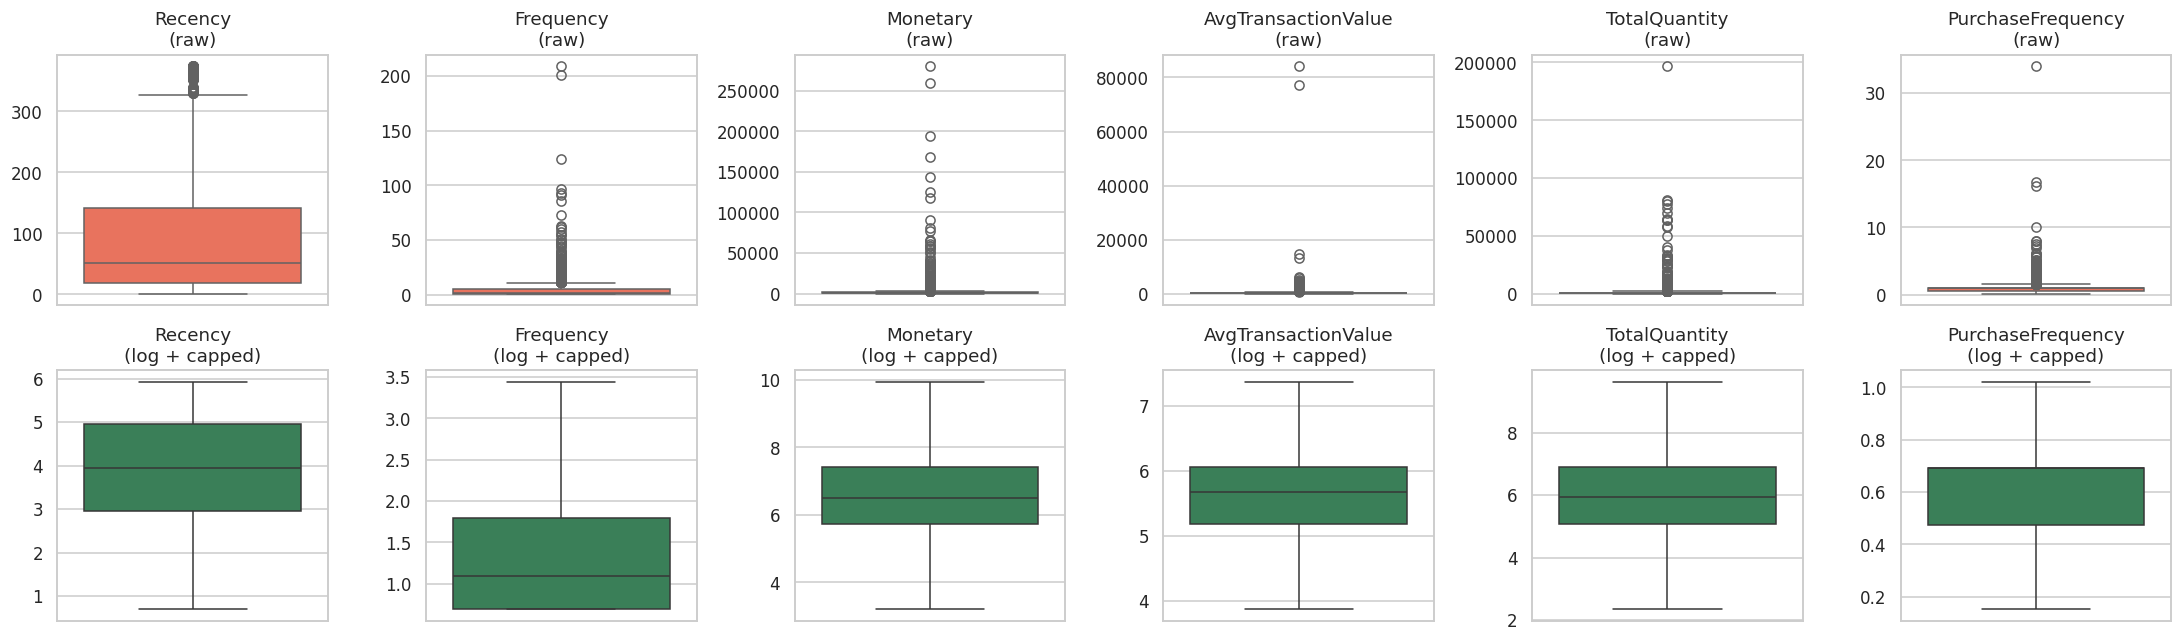

,count,mean,std,min,25%,50%,75%,max
Recency,4338.0,-0.0,1.0,-2.34,-0.66,0.09,0.84,1.56
Frequency,4338.0,-0.0,1.0,-0.97,-0.97,-0.36,0.68,3.16
Monetary,4338.0,-0.0,1.0,-2.76,-0.70,-0.06,0.68,2.75
AvgTransactionValue,4338.0,0.0,1.0,-2.56,-0.66,0.05,0.61,2.51
TotalQuantity,4338.0,-0.0,1.0,-2.74,-0.68,-0.03,0.69,2.75
PurchaseFrequency,4338.0,-0.0,1.0,-2.22,-0.75,0.24,0.24,1.74


In [7]:
fig, axes = plt.subplots(2, 6, figsize=(20, 6))
X_log = np.log1p(cust[FEATURES])

def cap_iqr(s):
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    return s.clip(q1 - 1.5 * iqr, q3 + 1.5 * iqr)

X_cap = X_log.apply(cap_iqr)

for i, f in enumerate(FEATURES):
    sns.boxplot(y=cust[f], ax=axes[0, i], color="tomato");   axes[0, i].set_title(f"{f}\n(raw)")
    sns.boxplot(y=X_cap[f], ax=axes[1, i], color="seagreen"); axes[1, i].set_title(f"{f}\n(log + capped)")
    axes[0, i].set_ylabel(""); axes[1, i].set_ylabel("")
plt.tight_layout(); plt.show()

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_cap), index=cust.index, columns=FEATURES)
X_scaled.describe().T.round(2)

## Elbow Method
Inertia (within-cluster sum of squares) is computed for K = 2..10. The "elbow" is where adding clusters stops giving a large reduction. The Silhouette Score per K is plotted as a supporting check.

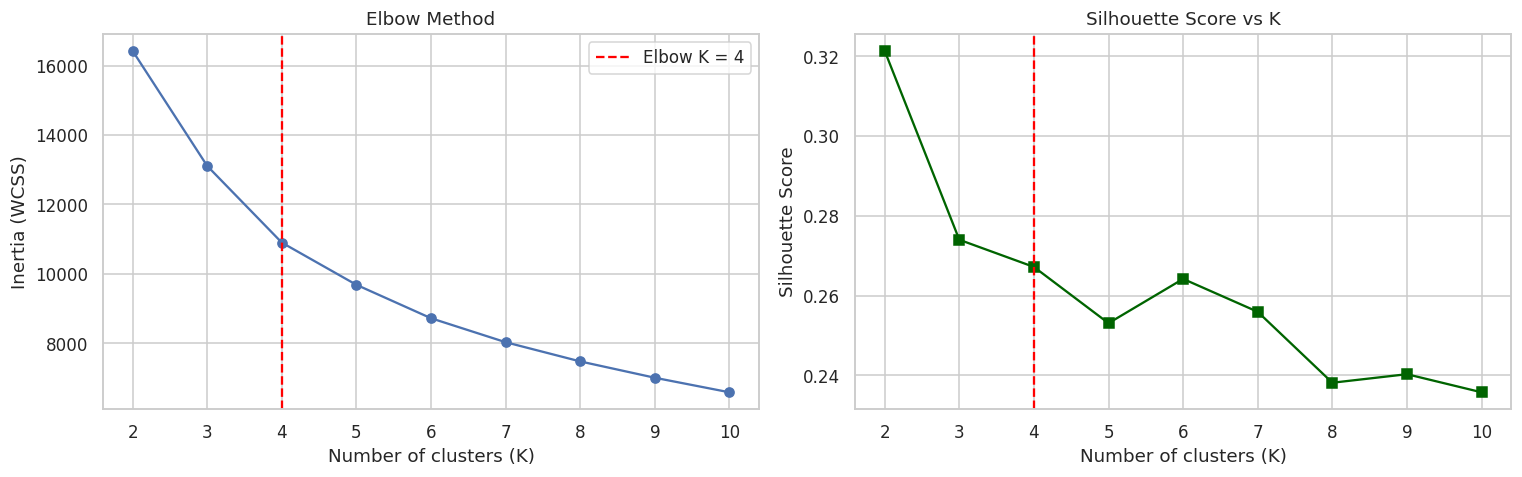

 K  Inertia  Silhouette
 2  16429.1      0.3214
 3  13110.9      0.2740
 4  10900.7      0.2672
 5   9684.1      0.2531
 6   8720.2      0.2642
 7   8029.3      0.2559
 8   7475.2      0.2382
 9   7004.4      0.2403
10   6585.2      0.2358

Selected K = 4


In [8]:
ks = list(range(2, 11))
inertias, sils = [], []
for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE).fit(X_scaled)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(X_scaled, km.labels_))

knee = KneeLocator(ks, inertias, curve="convex", direction="decreasing").elbow
K_OPT = int(knee) if knee else 4

fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
ax[0].plot(ks, inertias, "o-"); ax[0].axvline(K_OPT, color="red", ls="--", label=f"Elbow K = {K_OPT}")
ax[0].set(title="Elbow Method", xlabel="Number of clusters (K)", ylabel="Inertia (WCSS)"); ax[0].legend()
ax[1].plot(ks, sils, "s-", color="darkgreen"); ax[1].axvline(K_OPT, color="red", ls="--")
ax[1].set(title="Silhouette Score vs K", xlabel="Number of clusters (K)", ylabel="Silhouette Score")
plt.tight_layout(); plt.show()

print(pd.DataFrame({"K": ks, "Inertia": np.round(inertias, 1), "Silhouette": np.round(sils, 4)}).to_string(index=False))
print(f"\nSelected K = {K_OPT}")

## K-Means Customer Segmentation

In [9]:
kmeans = KMeans(n_clusters=K_OPT, n_init=10, random_state=RANDOM_STATE).fit(X_scaled)
cust["KMeans"] = kmeans.labels_
sil_km = silhouette_score(X_scaled, cust["KMeans"])

print(f"K-Means (K={K_OPT}) Silhouette Score: {sil_km:.4f}")
print("\nCluster sizes:")
print(cust["KMeans"].value_counts().sort_index())

K-Means (K=4) Silhouette Score: 0.2672

Cluster sizes:
KMeans
0    1061
1     790
2    1321
3    1166
Name: count, dtype: int64


## Hierarchical Clustering and Dendrogram
Ward linkage (minimises within-cluster variance, comparable to K-Means) on the same scaled features. The dendrogram is truncated to the last 30 merges for readability; the dashed line marks the cut that gives K clusters.

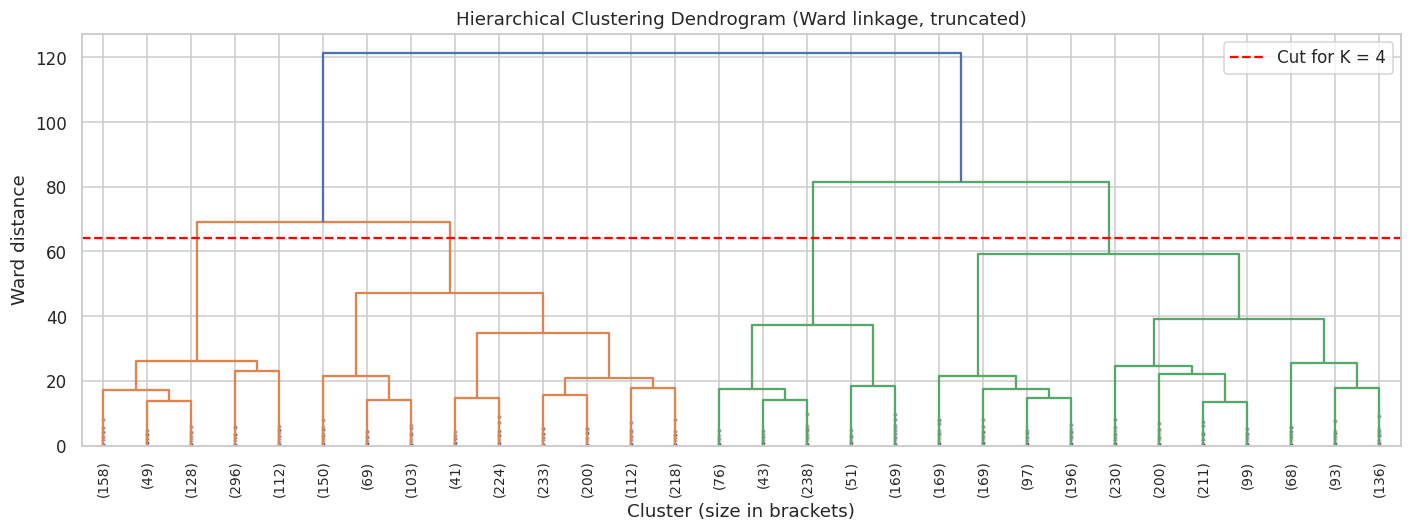

In [10]:
Z = linkage(X_scaled, method="ward")

plt.figure(figsize=(13, 5))
dendrogram(Z, truncate_mode="lastp", p=30, leaf_rotation=90, leaf_font_size=9, show_contracted=True)
cut_height = (Z[-(K_OPT - 1), 2] + Z[-K_OPT, 2]) / 2
plt.axhline(cut_height, color="red", ls="--", label=f"Cut for K = {K_OPT}")
plt.title("Hierarchical Clustering Dendrogram (Ward linkage, truncated)")
plt.xlabel("Cluster (size in brackets)"); plt.ylabel("Ward distance"); plt.legend()
plt.tight_layout(); plt.show()

hier = AgglomerativeClustering(n_clusters=K_OPT, linkage="ward").fit(X_scaled)
cust["Hierarchical"] = hier.labels_

## Silhouette Score and Comparison of Clustering Results

In [11]:
sil_h = silhouette_score(X_scaled, cust["Hierarchical"])
ari = adjusted_rand_score(cust["KMeans"], cust["Hierarchical"])

comparison = pd.DataFrame({
    "Method": ["K-Means", "Hierarchical (Ward)"],
    "Clusters": [K_OPT, K_OPT],
    "Silhouette Score": [round(sil_km, 4), round(sil_h, 4)],
})
display(comparison)
print(f"Adjusted Rand Index between the two segmentations: {ari:.4f}  (1 = identical)")

print("\nCross-tabulation (rows = K-Means cluster, columns = Hierarchical cluster):")
display(pd.crosstab(cust["KMeans"], cust["Hierarchical"]))

,Method,Clusters,Silhouette Score
0,K-Means,4,0.2672
1,Hierarchical (Ward),4,0.2032


Adjusted Rand Index between the two segmentations: 0.5348  (1 = identical)

Cross-tabulation (rows = K-Means cluster, columns = Hierarchical cluster):


Hierarchical,0,1,2,3
KMeans,,,,
0,120,228,0,713
1,191,95,504,0
2,1233,22,66,0
3,124,1005,7,30


## PCA Visualisation of Segments

Explained variance ratio: [0.562  0.1771] | total: 0.7391


,PC1,PC2
Recency,-0.344,0.398
Frequency,0.456,-0.358
Monetary,0.532,0.112
AvgTransactionValue,0.348,0.600
TotalQuantity,0.518,0.101
PurchaseFrequency,0.035,-0.575


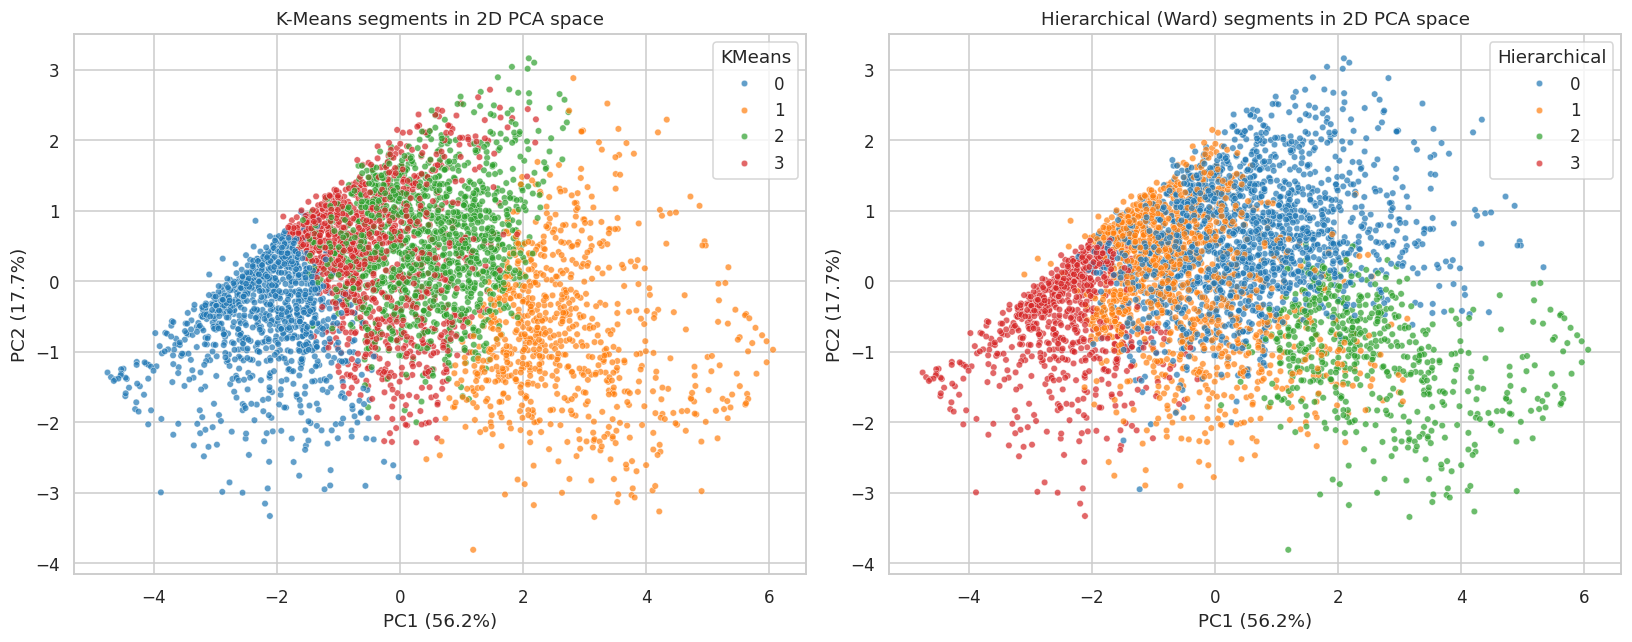

In [12]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
pcs = pca.fit_transform(X_scaled)
cust["PC1"], cust["PC2"] = pcs[:, 0], pcs[:, 1]
print("Explained variance ratio:", np.round(pca.explained_variance_ratio_, 4),
      "| total:", round(pca.explained_variance_ratio_.sum(), 4))

loadings = pd.DataFrame(pca.components_.T, index=FEATURES, columns=["PC1", "PC2"]).round(3)
display(loadings)

fig, ax = plt.subplots(1, 2, figsize=(15, 6))
for a, col, title in zip(ax, ["KMeans", "Hierarchical"], ["K-Means", "Hierarchical (Ward)"]):
    sns.scatterplot(data=cust, x="PC1", y="PC2", hue=col, palette="tab10", s=18, alpha=0.7, ax=a)
    a.set_title(f"{title} segments in 2D PCA space")
    a.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
    a.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.tight_layout(); plt.show()

## Cluster-wise Customer Profiling
Profiles use the **original (unscaled) values**. Clusters are named automatically from their characteristics: highest Monetary -> *Champions (High-Value)*; highest Recency (longest inactive) among the rest -> *At-Risk / Lost*; highest Frequency among the rest -> *Loyal Regulars*; the remainder -> *Occasional / New*.

,Customers,Recency,Frequency,Monetary,AvgTransactionValue,TotalQuantity,PurchaseFrequency,% Customers,% Revenue
Segment,,,,,,,,,
Champions (High-Value),790,20.66,12.92,7845.62,767.73,4518.88,1.57,18.2,69.7
Loyal Regulars,1321,51.09,3.75,1236.81,349.10,749.08,0.50,30.5,18.4
Occasional / New,1166,128.96,1.58,733.09,507.58,410.88,1.25,26.9,9.6
At-Risk / Lost,1061,157.62,1.43,189.03,143.48,106.95,1.06,24.5,2.3


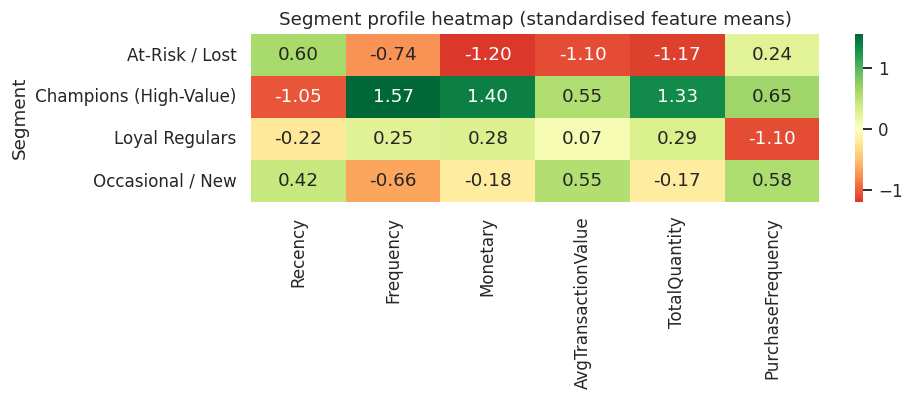

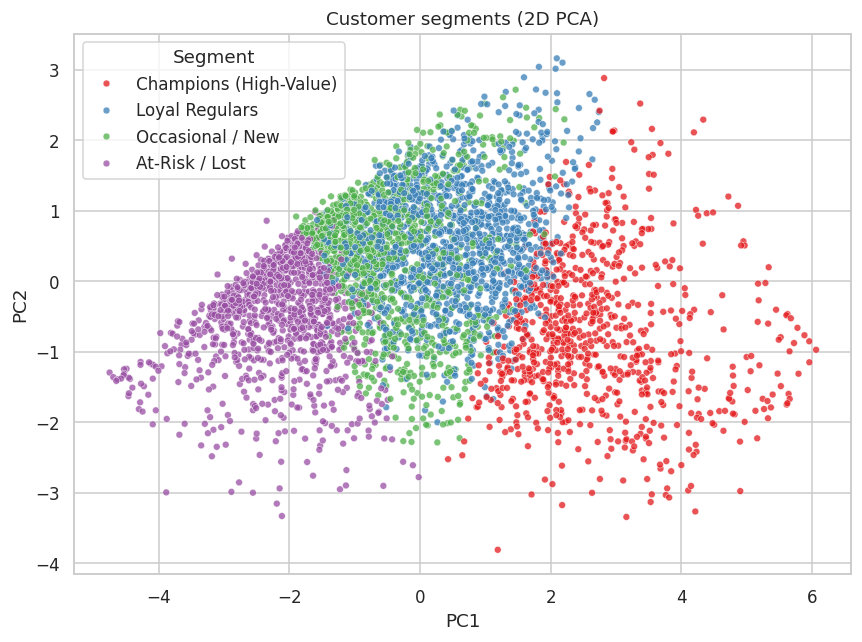

In [13]:
prof = cust.groupby("KMeans")[FEATURES].mean()

names, remaining = {}, list(prof.index)
champ = prof.loc[remaining, "Monetary"].idxmax();  names[champ] = "Champions (High-Value)"; remaining.remove(champ)
if remaining:
    lost = prof.loc[remaining, "Recency"].idxmax(); names[lost] = "At-Risk / Lost";           remaining.remove(lost)
if remaining:
    loyal = prof.loc[remaining, "Frequency"].idxmax(); names[loyal] = "Loyal Regulars";      remaining.remove(loyal)
for c in remaining:
    names[c] = "Occasional / New" if len(remaining) == 1 else f"Occasional / New #{c}"

cust["Segment"] = cust["KMeans"].map(names)

profile = cust.groupby("Segment").agg(
    Customers=("Recency", "size"),
    Recency=("Recency", "mean"),
    Frequency=("Frequency", "mean"),
    Monetary=("Monetary", "mean"),
    AvgTransactionValue=("AvgTransactionValue", "mean"),
    TotalQuantity=("TotalQuantity", "mean"),
    PurchaseFrequency=("PurchaseFrequency", "mean"),
    TotalRevenue=("Monetary", "sum"),
)
profile["% Customers"] = (profile["Customers"] / profile["Customers"].sum() * 100).round(1)
profile["% Revenue"]   = (profile["TotalRevenue"] / profile["TotalRevenue"].sum() * 100).round(1)
profile = profile.drop(columns="TotalRevenue").round(2).sort_values("Monetary", ascending=False)
display(profile)

z = X_scaled.assign(Segment=cust["Segment"]).groupby("Segment")[FEATURES].mean()
plt.figure(figsize=(9, 3.8))
sns.heatmap(z, annot=True, fmt=".2f", cmap="RdYlGn", center=0)
plt.title("Segment profile heatmap (standardised feature means)")
plt.tight_layout(); plt.show()

plt.figure(figsize=(8, 6))
sns.scatterplot(data=cust, x="PC1", y="PC2", hue="Segment", palette="Set1", s=20, alpha=0.75)
plt.title("Customer segments (2D PCA)"); plt.tight_layout(); plt.show()

**Interpretation (from the profile table above).**
- *Champions (High-Value)*: about 18% of customers but about 70% of revenue. Most recent (about 21 days), about 13 orders each, average spend about 7,846.
- *Loyal Regulars*: about 31% of customers, fairly recent (about 51 days), about 4 orders, moderate spend (about 1,237), about 18% of revenue.
- *Occasional / New*: about 27% of customers; last purchase about 129 days ago, roughly 1-2 orders, but a larger average basket (about 508) than the lowest segment. They are lapsing one-off or occasional buyers with some potential.
- *At-Risk / Lost*: about 25% of customers; the longest inactive (about 158 days), about 1 order, lowest spend (about 189) and only about 2% of revenue.

## Predicting High-Value Customers
**Target:** `1` if the customer belongs to the *Champions (High-Value)* cluster, else `0`.
Stratified 80/20 split; both models use `class_weight="balanced"` because the high-value class is a small minority.

> Note: the target is derived from a clustering of these same features, so high scores are expected. The goal here is to show that segment membership can be predicted and which features drive it, e.g. to score new customers without re-running clustering.

In [14]:
y = (cust["KMeans"] == champ).astype(int)
X = X_scaled.copy()

print("Class balance (1 = high-value):")
print(y.value_counts().rename({0: "Other", 1: "High-Value"}).to_frame("count").assign(pct=lambda d: (d["count"]/d["count"].sum()*100).round(2)))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)
print("\nTrain:", X_train.shape, " Test:", X_test.shape)

Class balance (1 = high-value):
            count    pct
KMeans                  
Other        3548  81.79
High-Value    790  18.21

Train: (3470, 6)  Test: (868, 6)


In [15]:
models = {
    "Random Forest": RandomForestClassifier(n_estimators=300, class_weight="balanced",
                                            random_state=RANDOM_STATE, n_jobs=-1),
    "SVM (RBF)":     SVC(kernel="rbf", C=1.0, gamma="scale", class_weight="balanced",
                         probability=True, random_state=RANDOM_STATE),
}

results, cms, probas = [], {}, {}
for name, model in models.items():
    model.fit(X_train, y_train)
    pred  = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1]
    probas[name] = proba
    cms[name] = confusion_matrix(y_test, pred)
    results.append({
        "Model": name,
        "Accuracy":  accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall":    recall_score(y_test, pred, zero_division=0),
        "F1-Score":  f1_score(y_test, pred, zero_division=0),
        "ROC-AUC":   roc_auc_score(y_test, proba),
    })
    print(f"===== {name} =====")
    print(classification_report(y_test, pred, target_names=["Other", "High-Value"], zero_division=0))

results_df = pd.DataFrame(results).set_index("Model").round(4)
print("Performance comparison:")
display(results_df)

===== Random Forest =====
              precision    recall  f1-score   support

       Other       0.99      0.99      0.99       710
  High-Value       0.96      0.96      0.96       158

    accuracy                           0.99       868
   macro avg       0.98      0.97      0.97       868
weighted avg       0.98      0.99      0.99       868

===== SVM (RBF) =====
              precision    recall  f1-score   support

       Other       1.00      0.98      0.99       710
  High-Value       0.93      1.00      0.96       158

    accuracy                           0.99       868
   macro avg       0.96      0.99      0.98       868
weighted avg       0.99      0.99      0.99       868

Performance comparison:


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Random Forest,0.9850,0.9618,0.9557,0.9587,0.9988
SVM (RBF),0.9862,0.9294,1.0000,0.9634,1.0000


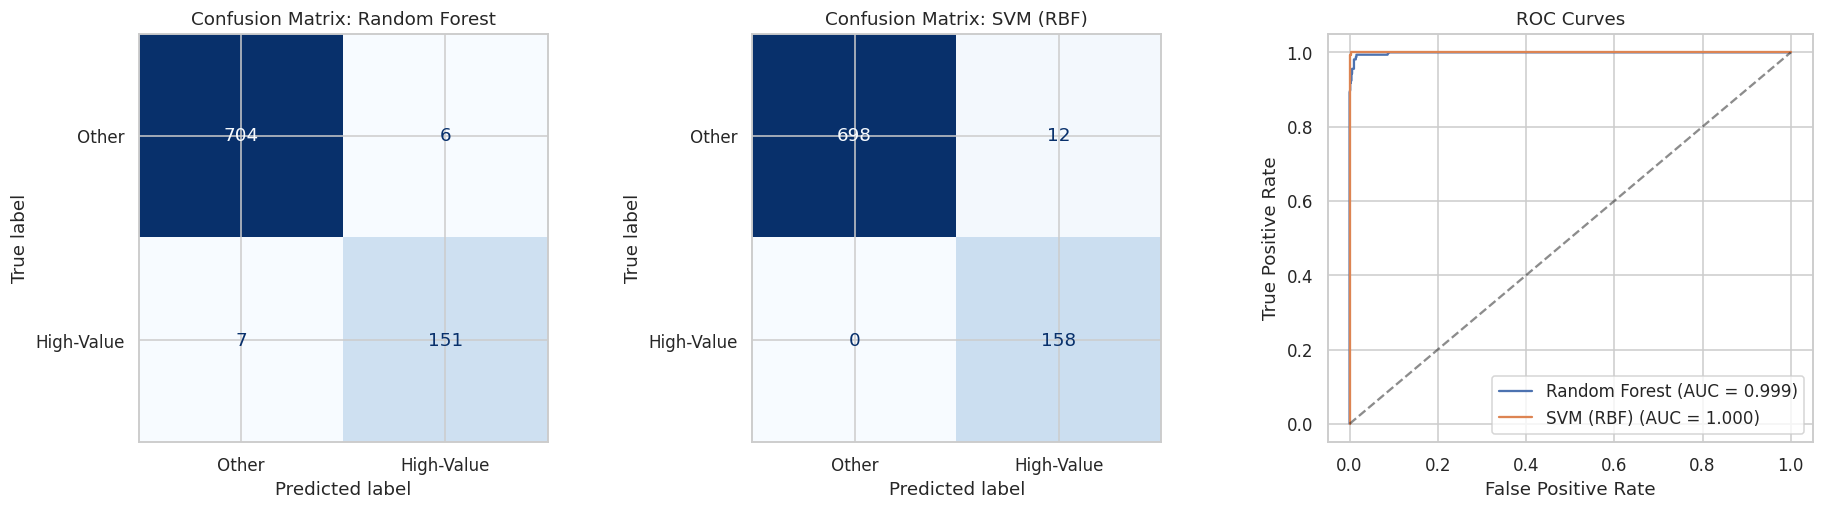

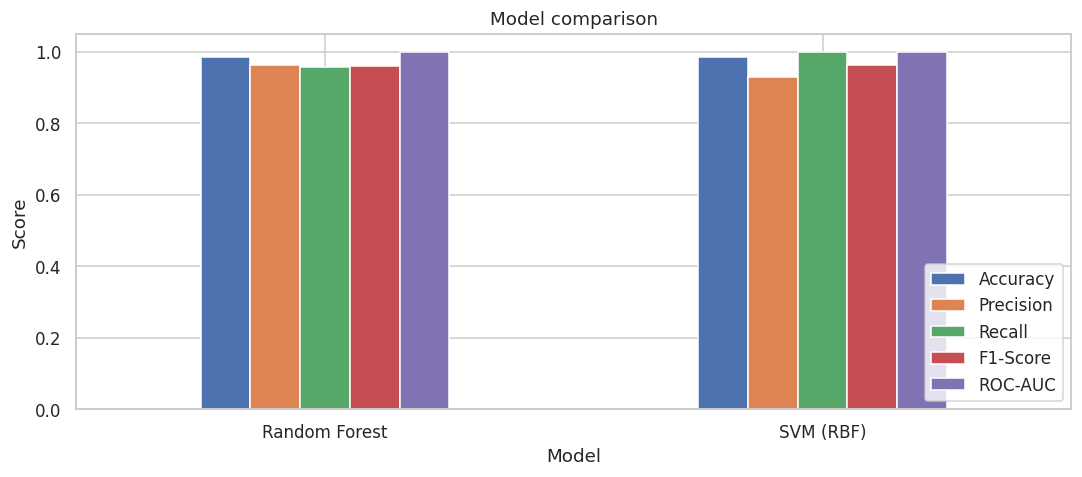

In [16]:
fig, ax = plt.subplots(1, 3, figsize=(17, 4.8))
for a, (name, cm) in zip(ax[:2], cms.items()):
    ConfusionMatrixDisplay(cm, display_labels=["Other", "High-Value"]).plot(ax=a, cmap="Blues", colorbar=False)
    a.set_title(f"Confusion Matrix: {name}")

for name, p in probas.items():
    fpr, tpr, _ = roc_curve(y_test, p)
    ax[2].plot(fpr, tpr, label=f"{name} (AUC = {roc_auc_score(y_test, p):.3f})")
ax[2].plot([0, 1], [0, 1], "k--", alpha=0.5)
ax[2].set(title="ROC Curves", xlabel="False Positive Rate", ylabel="True Positive Rate"); ax[2].legend()
plt.tight_layout(); plt.show()

results_df.plot(kind="bar", figsize=(10, 4.5), ylim=(0, 1.05), rot=0)
plt.title("Model comparison"); plt.ylabel("Score"); plt.legend(loc="lower right"); plt.tight_layout(); plt.show()

## Feature Importance
Two views for the Random Forest: (a) built-in impurity-based importance, and (b) permutation importance on the test set (drop in F1 when a feature is shuffled), which is less biased toward high-variance features.

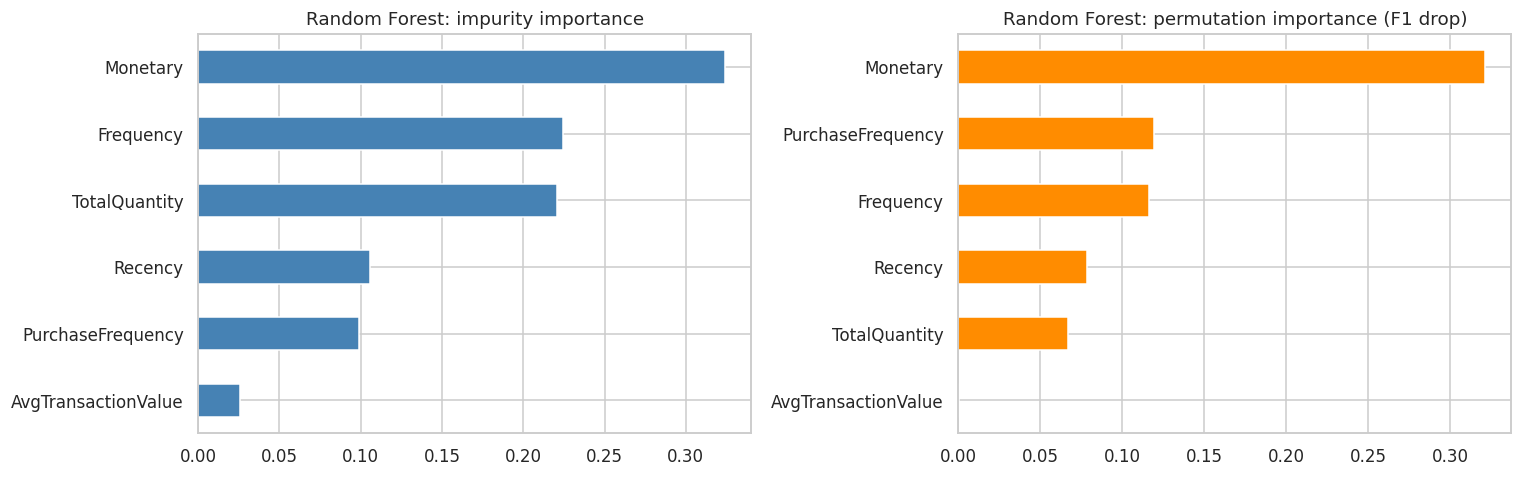

,Impurity importance,Permutation importance
Monetary,0.3241,0.3211
Frequency,0.2246,0.1163
TotalQuantity,0.2206,0.0668
Recency,0.1058,0.0787
PurchaseFrequency,0.0991,0.1192
AvgTransactionValue,0.0258,0.0007


In [17]:
rf = models["Random Forest"]
imp = pd.Series(rf.feature_importances_, index=FEATURES).sort_values()

perm = permutation_importance(rf, X_test, y_test, scoring="f1", n_repeats=15,
                              random_state=RANDOM_STATE, n_jobs=-1)
perm_s = pd.Series(perm.importances_mean, index=FEATURES).sort_values()

fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
imp.plot(kind="barh", ax=ax[0], color="steelblue");   ax[0].set_title("Random Forest: impurity importance")
perm_s.plot(kind="barh", ax=ax[1], color="darkorange"); ax[1].set_title("Random Forest: permutation importance (F1 drop)")
plt.tight_layout(); plt.show()

display(pd.DataFrame({"Impurity importance": imp, "Permutation importance": perm_s}).sort_values("Impurity importance", ascending=False).round(4))

## Interactive 3D Visualisation with Plotly
Axes: Recency, Frequency and Monetary (log scale, after capping). The plot is interactive in Colab (rotate, zoom, hover, click legend to hide segments). Interactive Plotly output does **not** appear in a printed PDF, so a static copy is generated right after it, and the interactive version is saved as `customer_clusters_3d.html`.

In [18]:
plot3d = X_cap[["Recency", "Frequency", "Monetary"]].copy()
plot3d.columns = ["log Recency", "log Frequency", "log Monetary"]
plot3d["Segment"] = cust["Segment"]
plot3d["CustomerID"] = cust.index

fig3d = px.scatter_3d(
    plot3d, x="log Recency", y="log Frequency", z="log Monetary",
    color="Segment", hover_name="CustomerID", opacity=0.75,
    title="Interactive 3D view of customer segments (RFM, log scale)")
fig3d.update_traces(marker=dict(size=3))
fig3d.update_layout(height=650, legend_title_text="Segment")
fig3d.write_html("customer_clusters_3d.html")
fig3d.show()

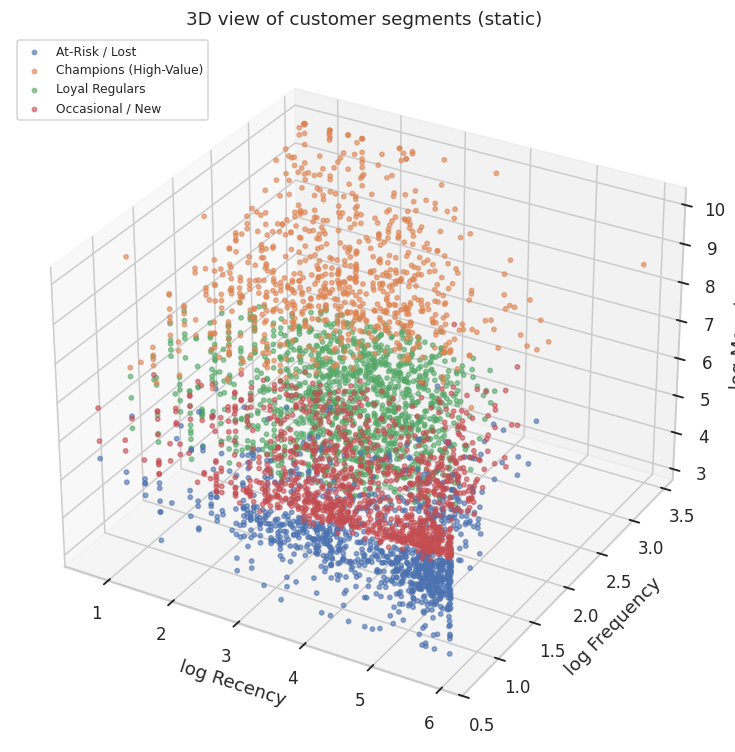

In [19]:
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")
for seg, d in plot3d.groupby("Segment"):
    ax.scatter(d["log Recency"], d["log Frequency"], d["log Monetary"], s=8, alpha=0.6, label=seg)
ax.set_xlabel("log Recency"); ax.set_ylabel("log Frequency"); ax.set_zlabel("log Monetary")
ax.set_title("3D view of customer segments (static)"); ax.legend(loc="upper left", fontsize=8)
plt.tight_layout(); plt.show()

## Segment-wise Targeted Marketing Recommendations

In [20]:
strategies = {
    "Champions (High-Value)": ("Reward and retain",
        "VIP / loyalty tier, early access to new products, personalised bundles, dedicated support, referral rewards. Avoid heavy discounting; they already buy at full price."),
    "Loyal Regulars": ("Grow basket value",
        "Cross-sell and upsell, volume or bundle offers, subscription / replenishment reminders, points programme to move them toward Champion status."),
    "Occasional / New": ("Build the habit",
        "Welcome series, second-purchase incentive, product recommendations based on first order, time-limited offers to raise frequency."),
    "At-Risk / Lost": ("Win back cost-effectively",
        "Win-back emails with a personalised discount, 'we miss you' campaigns, survey on why they left; cap spend since expected return is low."),
}
rows = []
for seg in profile.index:
    key = seg if seg in strategies else "Occasional / New"
    goal, tactics = strategies[key]
    rows.append({"Segment": seg, "Customers": int(profile.loc[seg, "Customers"]),
                 "% Revenue": profile.loc[seg, "% Revenue"], "Goal": goal, "Recommended actions": tactics})
pd.set_option("display.max_colwidth", None)
display(pd.DataFrame(rows))

,Segment,Customers,% Revenue,Goal,Recommended actions
0,Champions (High-Value),790,69.7,Reward and retain,"VIP / loyalty tier, early access to new products, personalised bundles, dedicated support, referral rewards. Avoid heavy discounting; they already buy at full price."
1,Loyal Regulars,1321,18.4,Grow basket value,"Cross-sell and upsell, volume or bundle offers, subscription / replenishment reminders, points programme to move them toward Champion status."
2,Occasional / New,1166,9.6,Build the habit,"Welcome series, second-purchase incentive, product recommendations based on first order, time-limited offers to raise frequency."
3,At-Risk / Lost,1061,2.3,Win back cost-effectively,"Win-back emails with a personalised discount, 'we miss you' campaigns, survey on why they left; cap spend since expected return is low."


## Interpretation of Results
- **Optimal K:** the Elbow Method selected K = 4. The silhouette score is highest at K = 2 (about 0.32) and then flattens around 0.25 to 0.27 for K = 3 to 10. K = 2 would only split active from inactive customers, so K = 4 was kept as the elbow choice because it gives four business-meaningful segments at a similar silhouette (about 0.27).
- **K-Means vs Hierarchical:** K-Means silhouette about 0.27 versus about 0.20 for Ward hierarchical clustering, so K-Means gives tighter and better-separated clusters. The Adjusted Rand Index of about 0.53 shows moderate agreement: the broad structure is the same but the borders between neighbouring segments differ.
- **PCA:** the first two components explain about 74% of the variance (PC1 about 56%, PC2 about 18%), so the 2D plot is a reliable picture. PC1 is an engagement axis (Monetary, TotalQuantity, Frequency load positively) and PC2 separates basket value and recency from purchase frequency (see the loadings table).
- **Segments:** Champions are about 18% of customers and about 70% of revenue, while At-Risk / Lost customers are about 25% of customers and about 2% of revenue.
- **Prediction:** Random Forest reached Accuracy 0.985, Precision 0.962, Recall 0.956, F1 0.959, ROC-AUC 0.999. SVM reached Accuracy 0.986, Precision 0.929, Recall 1.000, F1 0.963, ROC-AUC 1.000. SVM catches every high-value customer but raises more false alarms; Random Forest is more balanced and also gives feature importances.
- **Drivers:** Monetary is the strongest predictor in both importance views (about 0.32), followed by Frequency and TotalQuantity (impurity) or PurchaseFrequency and Frequency (permutation). AvgTransactionValue contributes almost nothing.

## Conclusion
Customer-level RFM-style features, after log transformation, outlier capping and scaling, produce well-separated segments. K-Means with the elbow-selected K gives interpretable segments, and Hierarchical clustering confirms the structure. A Random Forest and an SVM can accurately flag high-value customers, allowing the business to score new customers and apply the segment-specific strategies above: retain and reward Champions, grow Loyal Regulars, nurture new/occasional buyers and run low-cost win-back campaigns for At-Risk customers.
